# EDA Histórico Chat

---

## Objetivo

O objetivo desse notebook é realizar uma análise exploratória nos dados de chat histórico breve que serão utilizados posteriormente para predizer a autoria de cada mensagem. O notebook salvará um dataset de **treino** e **teste** do modelo.

---

## Código

---

In [ ]:
import re
import pandas as pd
import numpy as np

with open("../../dados/raw/chat.txt", "r") as f:
    texto = f.read()

pattern = r"\[(\d{1,2}/\d{1,2}/\d{2},\s*\d{1,2}:\d{2}:\d{2}\s*(?:AM|PM|am|pm))\]\s*(?!\s*[-~])([^\n:\]]+?):\s*(.*?)(?=\n\[\d{1,2}/\d{1,2}/\d{2},|\Z)"

matches = re.findall(pattern, texto, flags=re.DOTALL)

df = pd.DataFrame(matches, columns=["data_hora", "membro", "mensagem"])

df["mensagem"] = df["mensagem"].str.strip()

df["data_hora"] = pd.to_datetime(df["data_hora"], format = "%m/%d/%y, %I:%M:%S %p")

df = df[~df["membro"].isin(["Carlos", "Meta AI"])]

print("Primeiras linhas dos dados")
print(df.head())
print("Informações adicionais")
print(df.info())
print("Total de valores nulos")
print(df.isnull().sum())

Primeiras linhas dos dados
            data_hora   membro                        mensagem
0 2026-03-10 14:47:48  Luquete                     não precisa
1 2026-03-10 14:47:54  Luquete  e só colocar barco no enderman
2 2026-03-10 14:47:56    André       onde fica os piglin bruto
3 2026-03-10 14:47:58  Luquete       ele não consegue te bater
4 2026-03-10 14:48:04    André                     vai demorar
Informações adicionais
<class 'pandas.DataFrame'>
Index: 99487 entries, 0 to 99706
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   data_hora  99487 non-null  datetime64[us]
 1   membro     99487 non-null  str           
 2   mensagem   99487 non-null  str           
dtypes: datetime64[us](1), str(2)
memory usage: 6.2 MB
None
Total de valores nulos
data_hora    0
membro       0
mensagem     0
dtype: int64


In [5]:
def limpar_para_embedding(texto):
    texto = str(texto).strip().lower()
    # remove apenas artefatos do WhatsApp / sistema
    texto = re.sub(r"https?://\S+|www\.\S+", "", texto)

    texto = re.sub(
        r"\b(unknown|null|omitid[oa]s?|ocultad[oa]s?|"
        r"imagem|figurinha|audio|áudio|video|vídeo|"
        r"mensagem|apagad[oa]s?|media|anexo|voz|"
        r"documento|contato|editad[oa]s?)\b",
        "",
        texto
    )
    texto = re.sub(r"\s+", " ", texto).strip()

    return texto

df["mensagem_embedding"] = df["mensagem"].apply(
    limpar_para_embedding
)
df = df[df["mensagem_embedding"].str.len() > 0].reset_index(drop=True)

In [22]:
df = df.sort_values('data_hora')

df['grupo_5'] = df.groupby('membro').cumcount() // 5

df_consolidado = df.groupby(['membro', 'grupo_5'], as_index=False).agg(
    data_inicio=('data_hora', 'min'),
    data_fim=('data_hora', 'max'),
    mensagem=('mensagem_embedding', lambda msgs: ' '.join(msgs)),
    total_msgs=('mensagem_embedding', 'count')
)

df_consolidado['duracao_minutos'] = (
    df_consolidado['data_fim'] - df_consolidado['data_inicio']
).dt.total_seconds() / 60

print("Primeiras linhas dos dados")
print(df_consolidado.head())
print("Informações adicionais")
print(df_consolidado.info())
print("Total de valores nulos")
print(df_consolidado.isnull().sum())

Primeiras linhas dos dados
  membro  grupo_5         data_inicio            data_fim  \
0  André        0 2026-03-10 14:47:56 2026-03-10 14:48:33   
1  André        1 2026-03-10 14:48:36 2026-03-10 14:49:50   
2  André        2 2026-03-10 14:49:52 2026-03-10 15:21:52   
3  André        3 2026-03-10 15:21:52 2026-03-10 15:31:09   
4  André        4 2026-03-10 15:31:10 2026-03-10 15:49:33   

                                            mensagem  total_msgs  \
0  onde fica os piglin bruto vai demorar mil anos...           5   
1  barricando e tradando entendo dá pra gente fic...           5   
2  ir em 3 acho que aí dois lutam e um fica vigia...           5   
3  its over caralho ai vc vai la e faz outra cois...           5   
4  pqp n8n roncando goti eu tambem 19h da pra vocês?           5   

   duracao_minutos  
0         0.616667  
1         1.233333  
2        32.000000  
3         9.283333  
4        18.383333  
Informações adicionais
<class 'pandas.DataFrame'>
RangeIndex: 19745 ent

/tmp/ipykernel_78237/1660077616.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


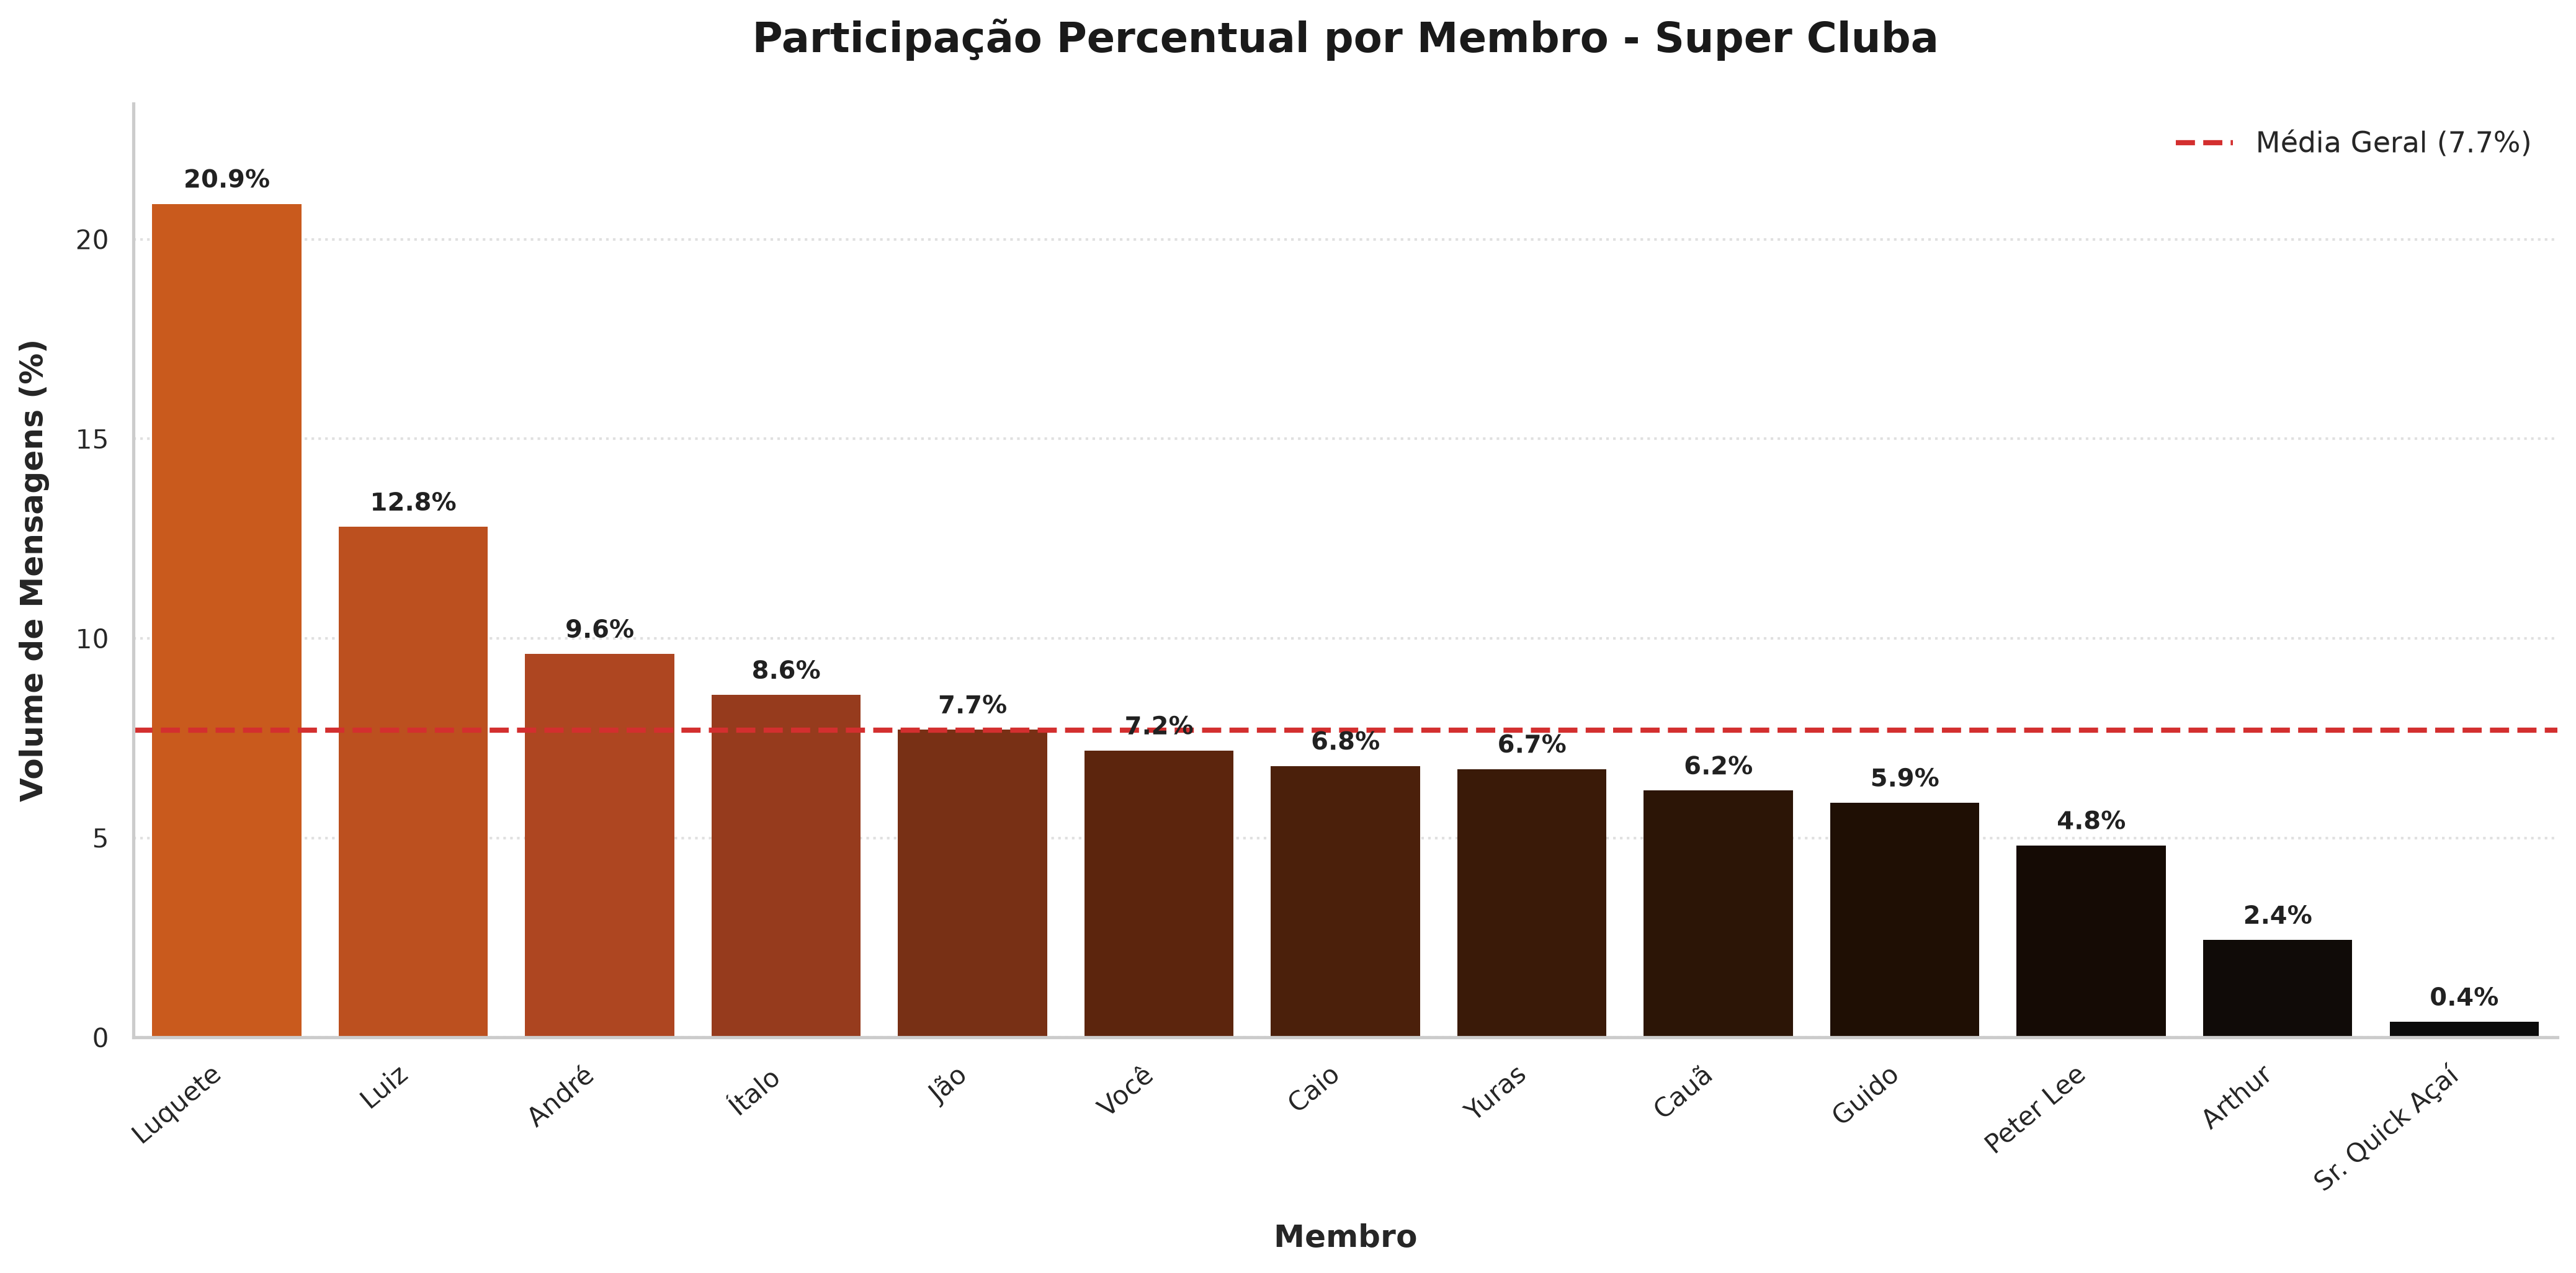

In [23]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

df_membros = df_consolidado["membro"].value_counts(normalize=True).reset_index()
df_membros.columns = ["membro", "percentual"]
df_membros["percentual"] = df_membros["percentual"] * 100

total_membros = len(df_membros)
media_percentual = df_membros["percentual"].mean()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7), dpi=300)

cores_degrade = ["#E65100", "#BF360C", "#6D2100", "#3E1700", "#1A0B00", "#0B0B0B"]
cmap_custom = mcolors.LinearSegmentedColormap.from_list(
    "laranja_preto", cores_degrade, N=total_membros
)
paleta = [cmap_custom(i / (total_membros - 1)) for i in range(total_membros)]

ax = sns.barplot(
    data=df_membros,
    x="membro",
    y="percentual",
    palette=paleta,
    edgecolor="none",
)

plt.axhline(
    y=media_percentual,
    color="#D32F2F",
    linestyle="--",
    linewidth=2,
    label=f"Média Geral ({media_percentual:.1f}%)",
)

for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(
            f"{altura:.1f}%",
            (p.get_x() + p.get_width() / 2.0, altura),
            ha="center",
            va="bottom",
            fontsize=9.5,
            fontweight="bold",
            color="#212121",
            xytext=(0, 4),
            textcoords="offset points",
        )

plt.title(
    "Participação Percentual por Membro - Super Cluba",
    fontsize=16,
    fontweight="bold",
    pad=20,
    color="#1A1A1A",
)
plt.xlabel("Membro", fontsize=12, fontweight="bold", labelpad=10)
plt.ylabel(
    "Volume de Mensagens (%)", fontsize=12, fontweight="bold", labelpad=10
)

plt.xticks(rotation=40, ha="right", fontsize=10, fontweight="medium")
plt.yticks(fontsize=10)
plt.ylim(0, df_membros["percentual"].max() * 1.12)

sns.despine(top=True, right=True)
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.legend(
    frameon=True,
    facecolor="white",
    edgecolor="none",
    fontsize=11,
    loc="upper right",
)

plt.tight_layout()
plt.show()

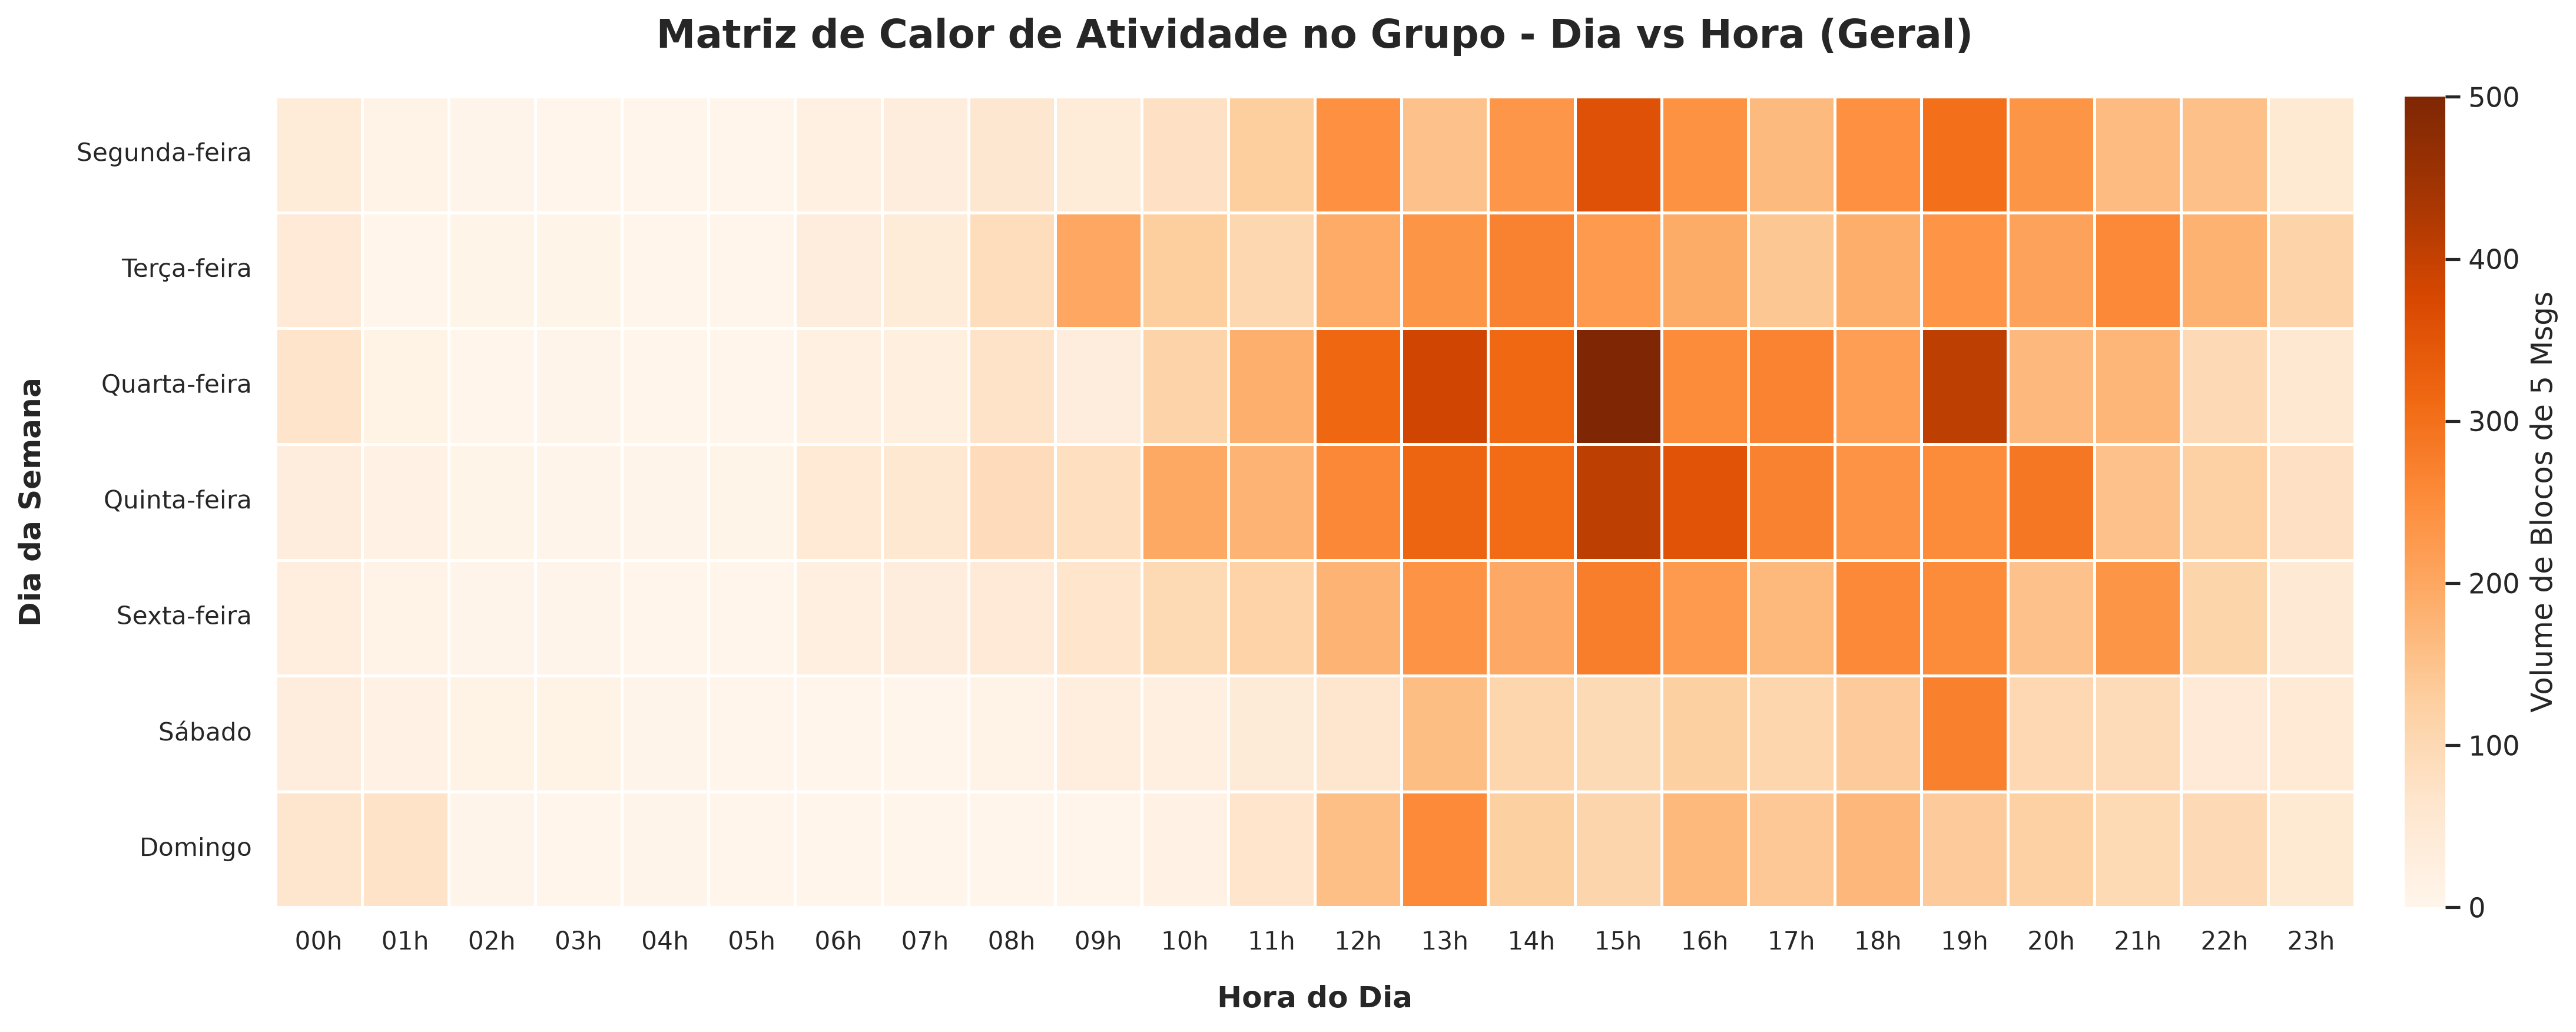

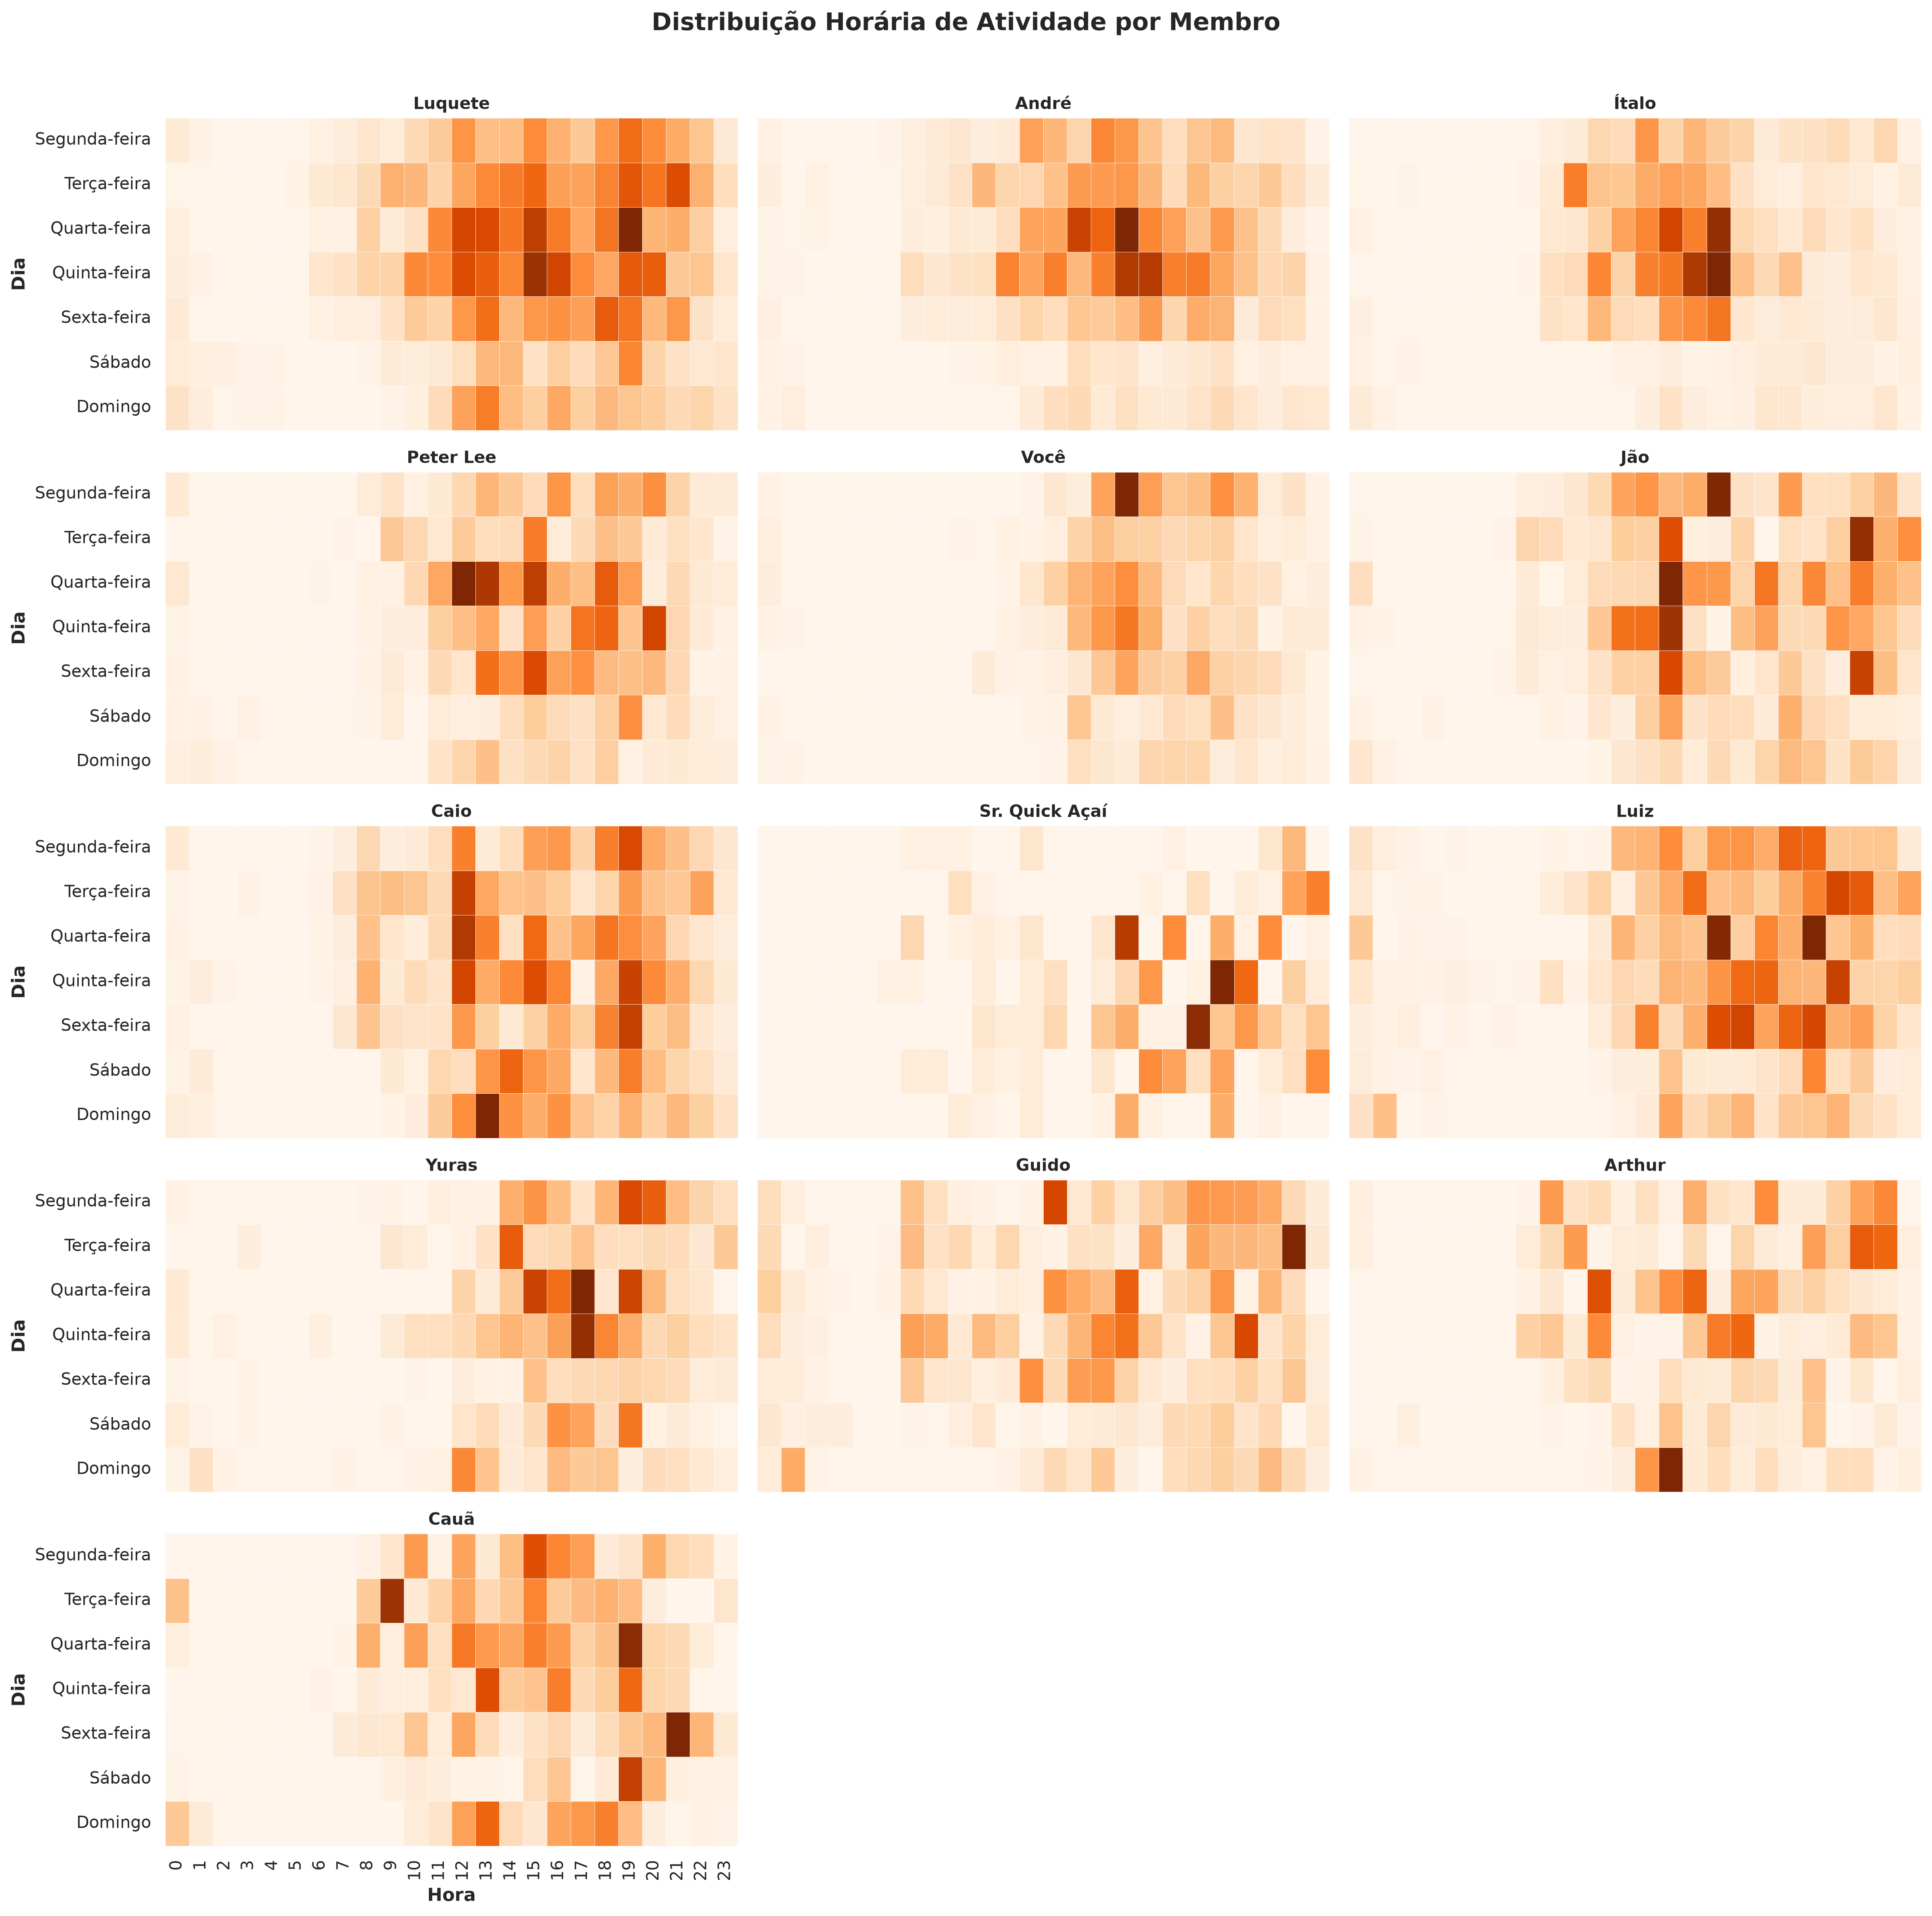

In [32]:
map_dias = {
    0: "Segunda-feira",
    1: "Terça-feira",
    2: "Quarta-feira",
    3: "Quinta-feira",
    4: "Sexta-feira",
    5: "Sábado",
    6: "Domingo",
}

dias_ordenados = [
    "Segunda-feira",
    "Terça-feira",
    "Quarta-feira",
    "Quinta-feira",
    "Sexta-feira",
    "Sábado",
    "Domingo",
]

df_consolidado["dia_semana_inicio"] = df_consolidado["data_inicio"].dt.dayofweek.map(map_dias)
df_consolidado["dia_semana_fim"] = df_consolidado["data_fim"].dt.dayofweek.map(map_dias)
df_consolidado["hora_inicio"] = df_consolidado["data_inicio"].dt.hour
df_consolidado["hora_fim"] = df_consolidado["data_fim"].dt.hour

df["dia"] = df["data_hora"].dt.dayofweek.map(map_dias)
df["hora"] = df["data_hora"].dt.hour

sns.set_theme(style="white")


matriz_geral = (
    pd.crosstab(
        df_consolidado["dia_semana_inicio"], df_consolidado["hora_inicio"]
    )
    .reindex(index=dias_ordenados, fill_value=0)
    .reindex(columns=range(24), fill_value=0)
)

plt.figure(figsize=(16, 6), dpi=300)

ax = sns.heatmap(
    matriz_geral,
    cmap="Oranges",
    annot=False,
    cbar_kws={"label": "Volume de Blocos de 5 Msgs", "pad": 0.02},
    linewidths=0.8,
    linecolor="white",
    square=False,
)

plt.title(
    "Matriz de Calor de Atividade no Grupo - Dia vs Hora (Geral)",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Hora do Dia", fontsize=12, fontweight="bold", labelpad=12)
plt.ylabel("Dia da Semana", fontsize=12, fontweight="bold", labelpad=12)

plt.xticks(
    ticks=np.arange(24) + 0.5,
    labels=[f"{h:02d}h" for h in range(24)],
    rotation=0,
    fontsize=10,
    fontweight="medium",
)

plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.show()

# --- 3. HEATMAPS INDIVIDUAIS POR MEMBRO (Subplots) ---

membros = df["membro"].unique()
num_membros = len(membros)

cols = 3
rows = (num_membros + cols - 1) // cols

fig, axes = plt.subplots(
    rows, cols, figsize=(18, rows * 3.5), sharex=True, sharey=True, dpi=300
)
axes = axes.flatten()

for i, membro in enumerate(membros):
    ax = axes[i]
    df_membro = df[df["membro"] == membro]

    matriz_membro = (
        pd.crosstab(df_membro["dia"], df_membro["hora"])
        .reindex(index=dias_ordenados, fill_value=0)
        .reindex(columns=range(24), fill_value=0)
    )

    sns.heatmap(
        matriz_membro,
        cmap="Oranges",
        cbar=False,
        ax=ax,
        linewidths=0.2,
        linecolor="#fafafa",
    )

    ax.set_title(f"{membro}", fontsize=11, fontweight="bold")
    ax.set_xlabel("" if i < (rows - 1) * cols else "Hora", fontweight="bold")
    ax.set_ylabel("" if i % cols != 0 else "Dia", fontweight="bold")
    ax.tick_params(axis="y", rotation=0)

# Oculta subplots vazios caso o número de membros não preencha a grade
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Distribuição Horária de Atividade por Membro",
    fontsize=16,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_78237/2038770589.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


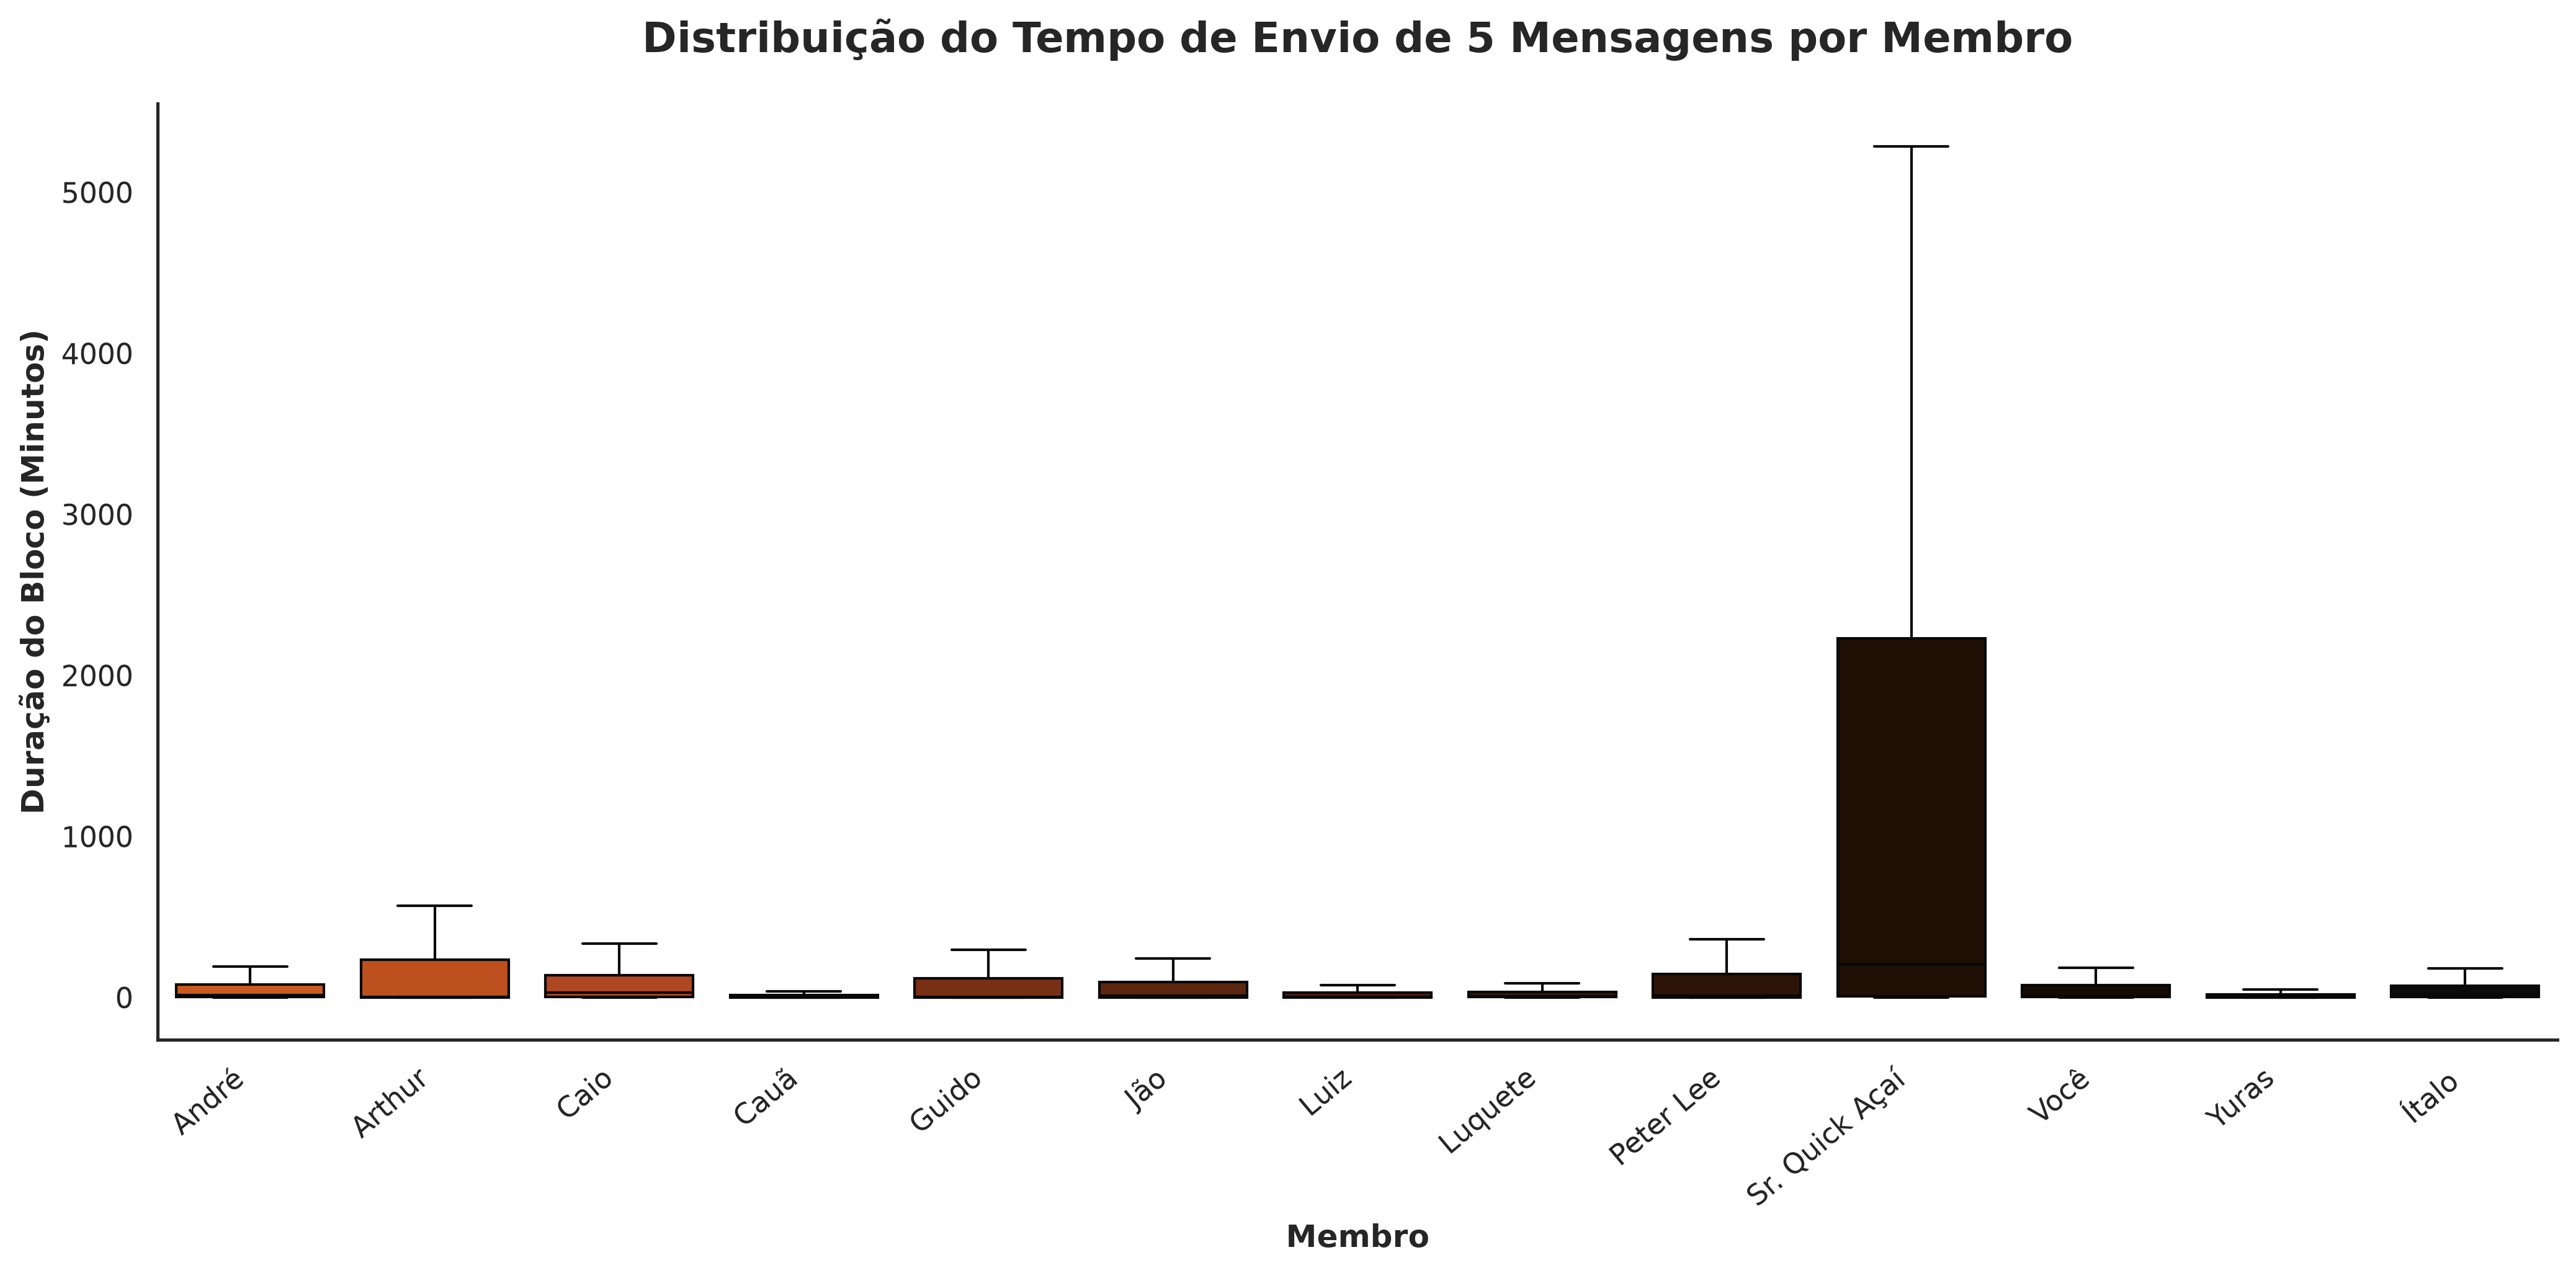

In [25]:
plt.figure(figsize=(14, 7), dpi=300)

sns.boxplot(
    data=df_consolidado,
    x="membro",
    y="duracao_minutos",
    palette=paleta,
    showfliers=False,  # Oculta outliers extremos para manter a escala legível
)

plt.title(
    "Distribuição do Tempo de Envio de 5 Mensagens por Membro",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Membro", fontsize=12, fontweight="bold")
plt.ylabel("Duração do Bloco (Minutos)", fontsize=12, fontweight="bold")
plt.xticks(rotation=40, ha="right")

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_78237/4117394491.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


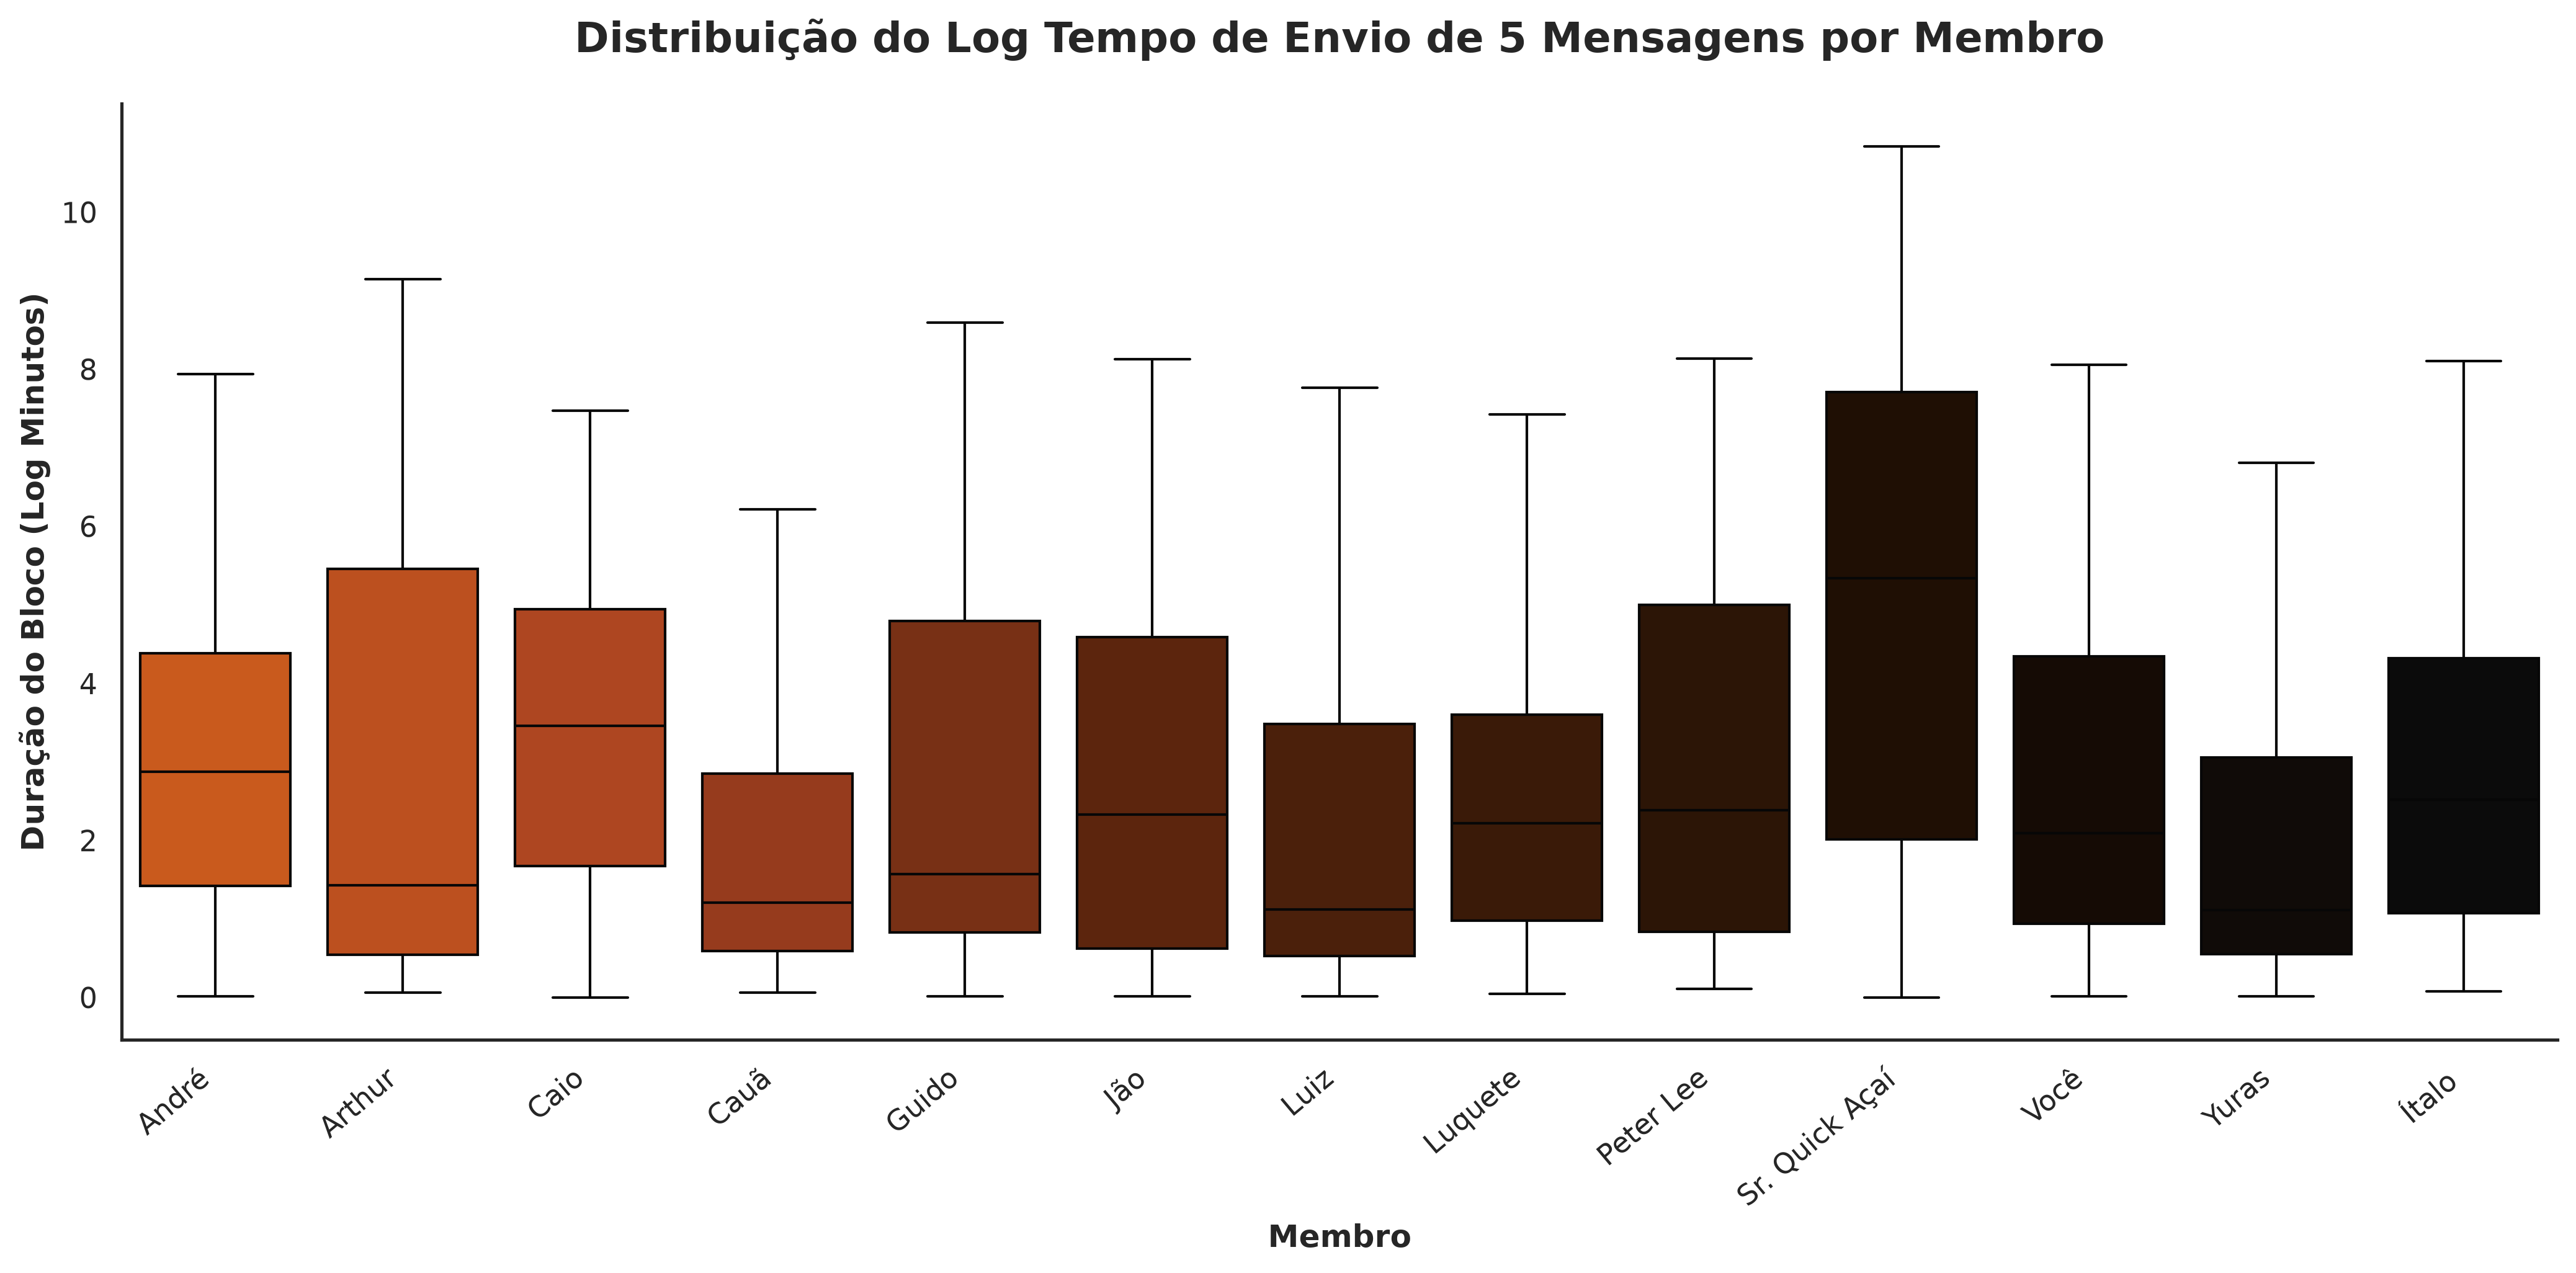

In [26]:
df_consolidado["log_duracao"] = np.log1p(df_consolidado["duracao_minutos"])

plt.figure(figsize=(14, 7), dpi=300)

sns.boxplot(
    data=df_consolidado,
    x="membro",
    y="log_duracao",
    palette=paleta,
    showfliers=False,  # Oculta outliers extremos para manter a escala legível
)

plt.title(
    "Distribuição do Log Tempo de Envio de 5 Mensagens por Membro",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Membro", fontsize=12, fontweight="bold")
plt.ylabel("Duração do Bloco (Log Minutos)", fontsize=12, fontweight="bold")
plt.xticks(rotation=40, ha="right")

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

--- Tabela Descritiva de Densidade Textual ---
        membro  total_msgs  mediana_palavras  media_palavras  max_palavras  media_caracteres
          Caio        1343              23.0       26.950856           345        165.644080
       Luquete        4124              25.0       26.610572          1094        148.313531
          Você        1419              23.0       26.042988           727        143.006342
         Yuras        1328              20.0       24.792922          1148        139.259036
          Luiz        2526              22.0       23.129454           480        139.006334
     Peter Lee         950              20.0       22.226316           150        126.769474
Sr. Quick Açaí          77              19.0       21.298701            45        109.389610
         André        1897              19.0       21.293622           446        134.351608
        Arthur         482              17.0       21.095436           525        116.184647
         Ítalo        1

/tmp/ipykernel_78237/1089312851.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


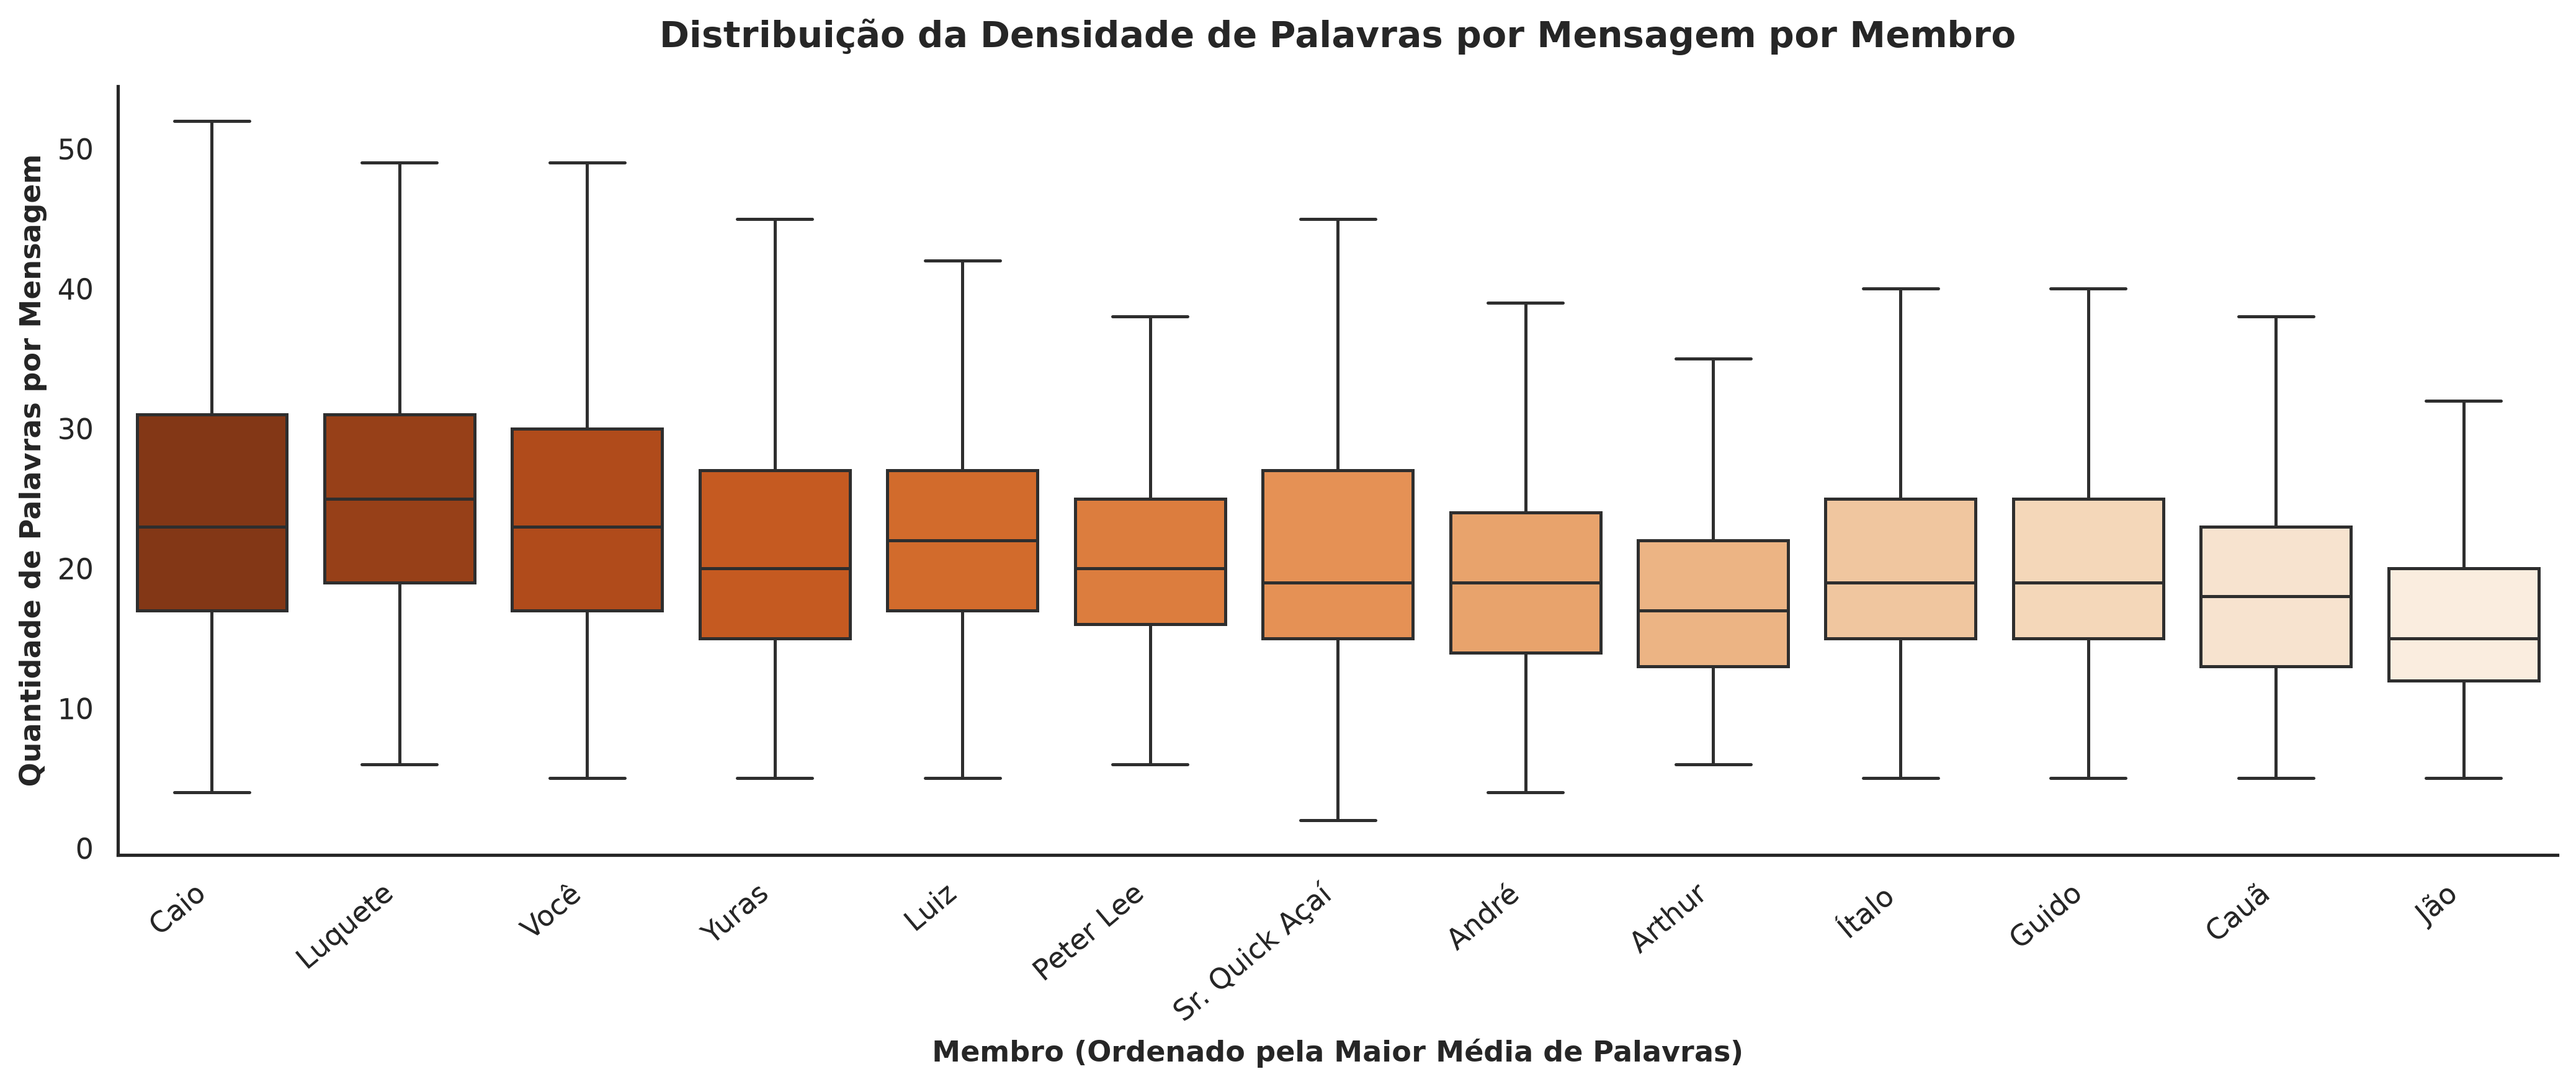

In [29]:
df_consolidado["qtd_caracteres"] = df_consolidado["mensagem"].astype(str).str.len()
df_consolidado["qtd_palavras"] = (
    df_consolidado["mensagem"].astype(str).apply(lambda x: len(x.split()))
)

estatisticas_texto = (
    df_consolidado.groupby("membro")
    .agg(
        total_msgs=("mensagem", "count"),
        mediana_palavras=("qtd_palavras", "median"),
        media_palavras=("qtd_palavras", "mean"),
        max_palavras=("qtd_palavras", "max"),
        media_caracteres=("qtd_caracteres", "mean"),
    )
    .sort_values("media_palavras", ascending=False)
    .reset_index()
)

print("--- Tabela Descritiva de Densidade Textual ---")
print(estatisticas_texto.to_string(index=False))

plt.figure(figsize=(14, 6), dpi=300)

ax = sns.boxplot(
    data=df_consolidado,
    x="membro",
    y="qtd_palavras",
    order=estatisticas_texto["membro"],
    palette="Oranges_r",
    showfliers=False,  # Esconde os outliers gigantes (textões isolados) para não achatar a escala
    linewidth=1.2,
)

plt.title(
    "Distribuição da Densidade de Palavras por Mensagem por Membro",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Membro (Ordenado pela Maior Média de Palavras)", fontsize=11, fontweight="bold")
plt.ylabel("Quantidade de Palavras por Mensagem", fontsize=11, fontweight="bold")
plt.xticks(rotation=40, ha="right")

sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_78237/395344796.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


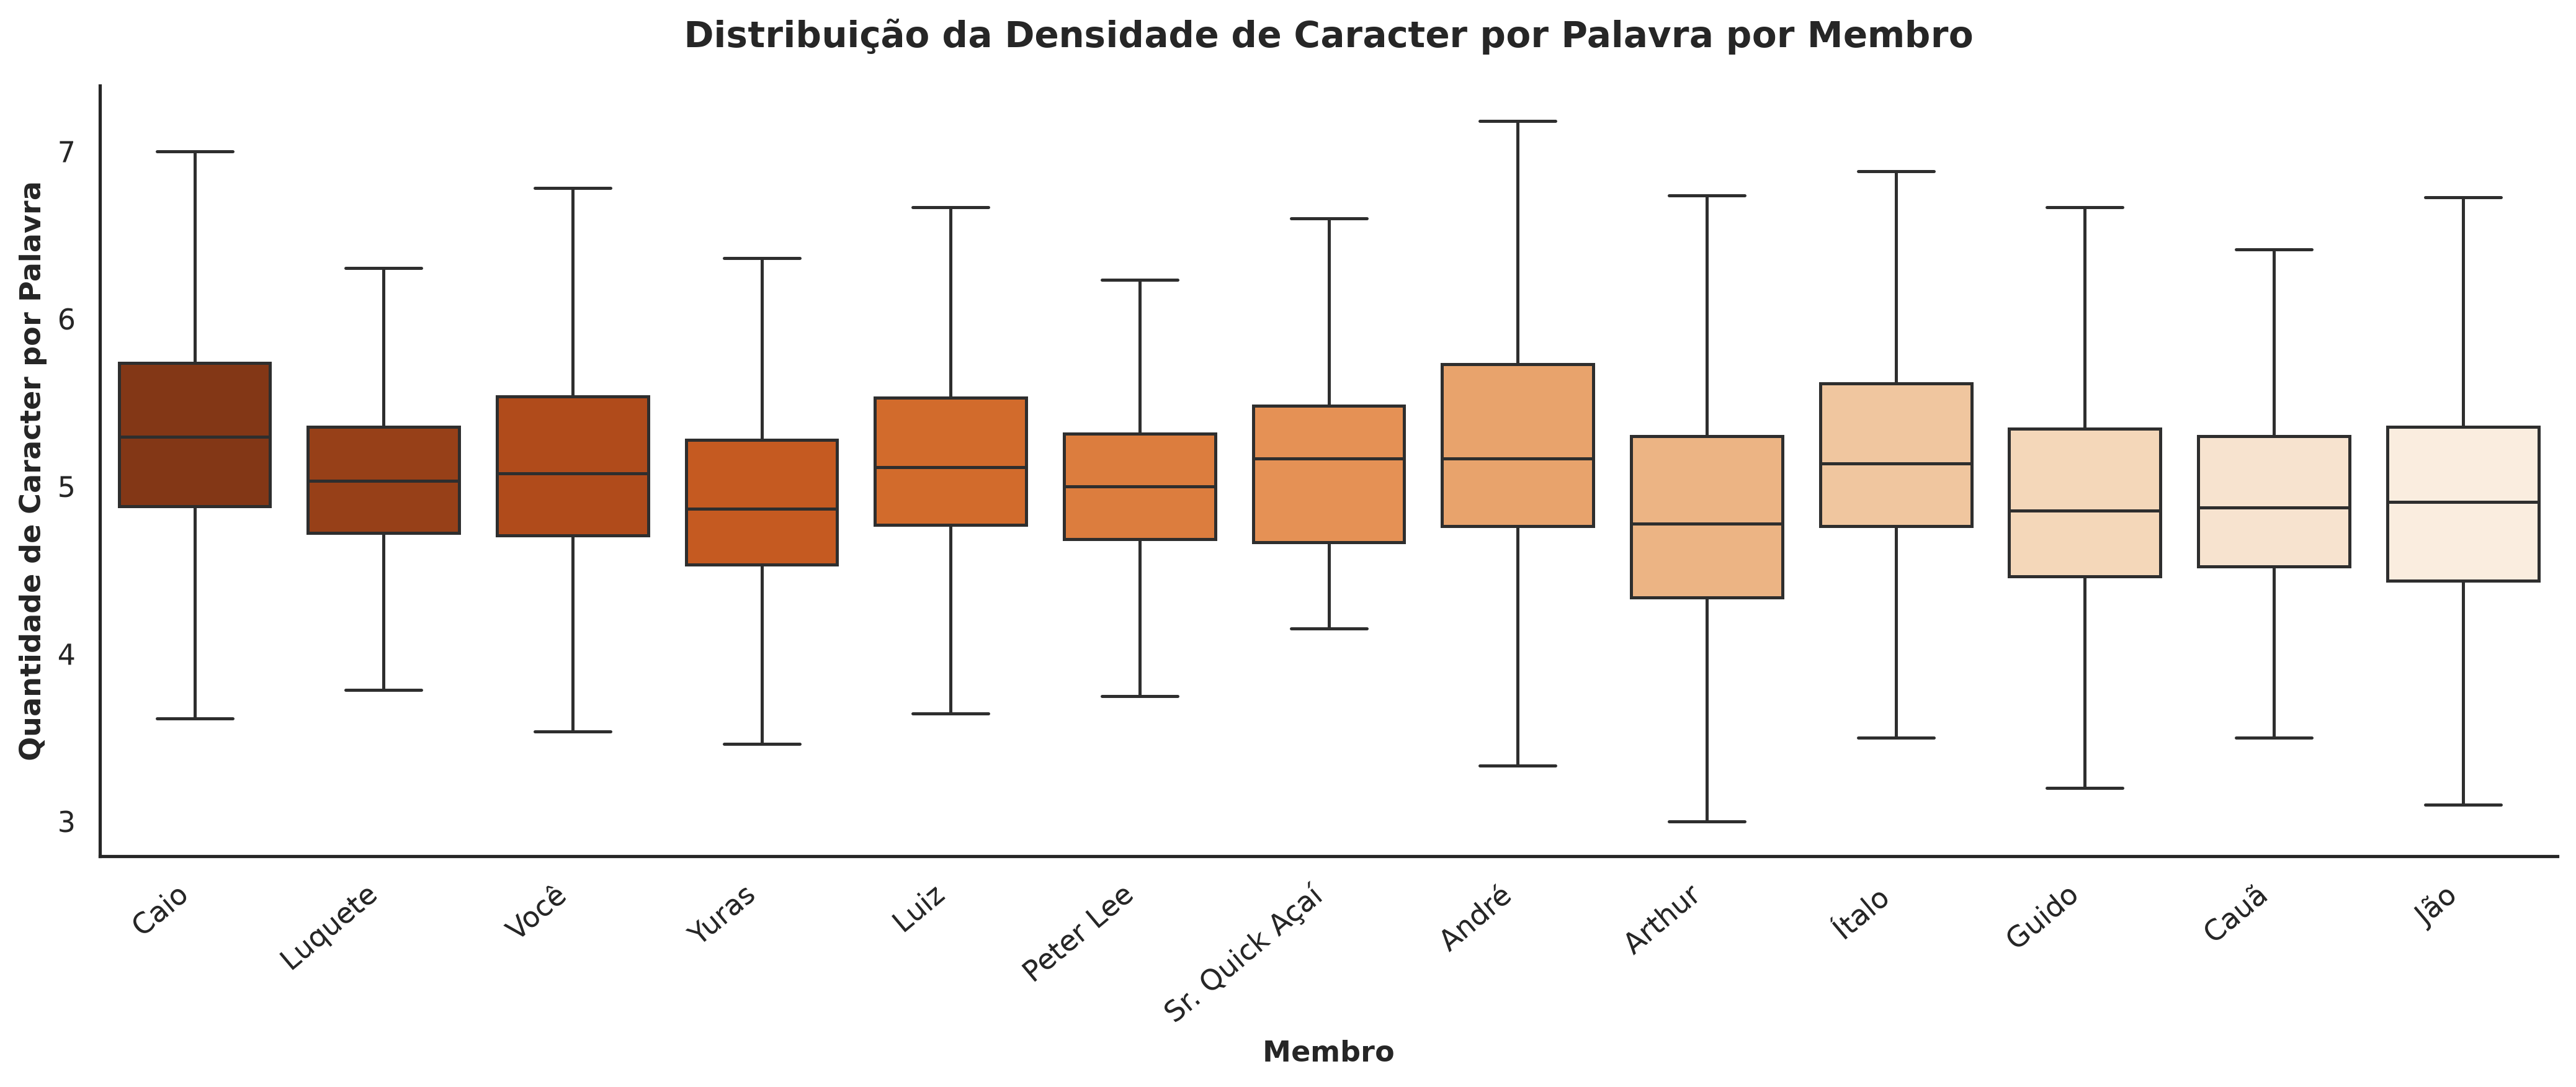

In [34]:
df_consolidado["caracter_por_palavra"] = (df_consolidado["qtd_caracteres"] / df_consolidado["qtd_palavras"]).clip(lower=1)

plt.figure(figsize=(14, 6), dpi=300)

ax = sns.boxplot(
    data=df_consolidado,
    x="membro",
    y="caracter_por_palavra",
    order=estatisticas_texto["membro"],
    palette="Oranges_r",
    showfliers=False,
    linewidth=1.2,
)

plt.title(
    "Distribuição da Densidade de Caracter por Palavra por Membro",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Membro", fontsize=11, fontweight="bold")
plt.ylabel("Quantidade de Caracter por Palavra", fontsize=11, fontweight="bold")
plt.xticks(rotation=40, ha="right")

sns.despine()
plt.tight_layout()
plt.show()

In [36]:
df_clean = df_consolidado[["membro", "mensagem", "log_duracao", "dia_semana_inicio", "dia_semana_fim", "hora_inicio", "hora_fim", "qtd_caracteres", "qtd_palavras", "caracter_por_palavra"]]

print("Primeiras linhas dos dados")
print(df_clean.head())
print("Informações adicionais")
print(df_clean.info())
print("Total de valores nulos")
print(df_clean.isnull().sum())

Primeiras linhas dos dados
  membro                                           mensagem  log_duracao  \
0  André  onde fica os piglin bruto vai demorar mil anos...     0.480366   
1  André  barricando e tradando entendo dá pra gente fic...     0.803495   
2  André  ir em 3 acho que aí dois lutam e um fica vigia...     3.496508   
3  André  its over caralho ai vc vai la e faz outra cois...     2.330524   
4  André  pqp n8n roncando goti eu tambem 19h da pra vocês?     2.964414   

  dia_semana_inicio dia_semana_fim  hora_inicio  hora_fim  qtd_caracteres  \
0       Terça-feira    Terça-feira           14        14              86   
1       Terça-feira    Terça-feira           14        14             145   
2       Terça-feira    Terça-feira           14        15             174   
3       Terça-feira    Terça-feira           15        15             111   
4       Terça-feira    Terça-feira           15        15              49   

   qtd_palavras  caracter_por_palavra  
0            

In [37]:
from sklearn.model_selection import train_test_split

y = df_clean["membro"]
X = df_clean.drop(columns=["membro"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

In [38]:
print("Primeiras linhas dos dados de treino")
print(df_train.head())
print("Informações adicionais de treino")
print(df_train.info())
print("Total de valores nulos de treino")
print(df_train.isnull().sum())

Primeiras linhas dos dados de treino
                                                mensagem  log_duracao  \
13335  irmão me fala o que a inglaterra vai arrumar c...     1.352393   
2490   se preparem para dormir aqui pode po pera no s...     7.083835   
85     desgraça kkkkkkkkkkkkk perdigueiro dinâmico al...     6.692104   
16271  é aqui no es eu ja sou explorado porra pelo me...     0.725937   
44     nada a ver <gif > @jão o radmin tá minerando b...     2.656757   

      dia_semana_inicio dia_semana_fim  hora_inicio  hora_fim  qtd_caracteres  \
13335       Terça-feira    Terça-feira           17        18              93   
2490             Sábado        Domingo           14        10              87   
85         Quinta-feira    Sexta-feira           22        11              77   
16271      Quinta-feira   Quinta-feira           14        14              94   
44         Quarta-feira   Quarta-feira           20        21             146   

       qtd_palavras  caracter_por_pal

In [39]:
print("Primeiras linhas dos dados de teste")
print(df_test.head())
print("Informações adicionais de teste")
print(df_test.info())
print("Total de valores nulos de teste")
print(df_test.isnull().sum())

Primeiras linhas dos dados de teste
                                                mensagem  log_duracao  \
10455  @jão vocês falam isso mas não sabem o vivek qu...     4.554052   
1829   se tivesse carro até ali na ufes de volta era ...     1.029619   
9640   vdd meu deus eles tiveram que inventar uma div...     0.659246   
8228   eu ando sempre acima de 80 exceto em bairro n ...     0.510826   
19554  ahhhhhhh pronto kkkkkkkkkk @luiz olha isso ???...     0.275103   

      dia_semana_inicio dia_semana_fim  hora_inicio  hora_fim  qtd_caracteres  \
10455       Sexta-feira    Sexta-feira           15        16             126   
1829       Quinta-feira   Quinta-feira           16        16             186   
9640        Terça-feira    Terça-feira            0         0              95   
8228        Terça-feira    Terça-feira           14        14             109   
19554      Quarta-feira   Quarta-feira           15        15              80   

       qtd_palavras  caracter_por_pala

In [40]:
df_train.to_parquet("../../dados/processed/train.parquet", index=False)
df_test.to_parquet("../../dados/processed/test.parquet", index=False)